# Анализ датасета и предсказаний модели с помощью FiftyOne

Подключаем хранилище в docker

```bash
docker run -d \
  --network host \
  --name fiftyone-mongodb \
  -v fiftyone-mongodb-data:/data/db \
  mongo:7.0
```

Запускаем docker контейнер с MongoDB c уже подключенным хранилищем

```bash
docker start fiftyone-mongodb
```

In [14]:
import os
# Устанавливаем URI для подключения к MongoDB
os.environ['FIFTYONE_DATABASE_URI'] = "mongodb://localhost:27017"

print(f"FiftyOne будет использовать MongoDB по адресу: {os.environ['FIFTYONE_DATABASE_URI']}")

FiftyOne будет использовать MongoDB по адресу: mongodb://localhost:27017


In [15]:
import fiftyone as fo
import fiftyone.zoo as foz
from fiftyone import ViewField as F
from ultralytics import YOLO
from fiftyone import Detection, Detections
import yaml
from pathlib import Path
import torch
import gc
from collections import Counter
import re
from collections import defaultdict

## 1. Определение путей

Определяем все необходимые пути к данным и артефактам относительно расположения этого ноутбука

In [16]:
# Путь к директории, где находится этот ноутбук
NOTEBOOK_DIR = Path().resolve()

# Путь к корню проекта
PROJECT_ROOT = NOTEBOOK_DIR.parents[3]

# Путь к датасету
DATASET_PATH = PROJECT_ROOT / 'master-thesis/damage-analysis/data/detection/processed/final_dataset'

# Путь к весам модели
MODEL_PATH = PROJECT_ROOT / 'master-thesis/damage-analysis/models/detection/experiment_3/best.pt'

# Путь для хранения базы данных FiftyOne
FIFTYONE_DB_PATH = PROJECT_ROOT / 'master-thesis/damage-analysis/fiftyone_db'

# Имя датасета в FiftyOne
DATASET_NAME = "facade-damage-local"

# Путь к файлу data.yaml, который мы создадим
dataset_yaml_path = DATASET_PATH / 'data.yaml'

print(f"Корень проекта: {PROJECT_ROOT}")
print(f"Путь к датасету: {DATASET_PATH}")
print(f"Путь к модели: {MODEL_PATH}")
print(f"Путь к БД FiftyOne: {FIFTYONE_DB_PATH}")

# Проверим, что пути существуют
assert DATASET_PATH.exists(), f"Папка с датасетом не найдена: {DATASET_PATH}"
assert MODEL_PATH.exists(), f"Файл модели не найден: {MODEL_PATH}"

Корень проекта: /home/neuralist/HSE_AI_master/deep-learning
Путь к датасету: /home/neuralist/HSE_AI_master/deep-learning/master-thesis/damage-analysis/data/detection/processed/final_dataset
Путь к модели: /home/neuralist/HSE_AI_master/deep-learning/master-thesis/damage-analysis/models/detection/experiment_3/best.pt
Путь к БД FiftyOne: /home/neuralist/HSE_AI_master/deep-learning/master-thesis/damage-analysis/fiftyone_db


## 2. Создание файла `data.yaml`

Необходим для `YOLO` и `FiftyOne`, чтобы понимать структуру датасета.

In [ ]:
# dataset_yaml = {
#     'train': str(DATASET_PATH / 'images/train'),  
#     'val': str(DATASET_PATH / 'images/val'),      
#     'test': str(DATASET_PATH / 'images/test'),   
#     'names': {0: 'crack', 1: 'corrosion', 2: 'delamination',
#               3: 'dirt_mold', 4: 'paint_defect'}
# }

# with open(dataset_yaml_path, 'w') as f:
#     yaml.dump(dataset_yaml, f, default_flow_style=False, sort_keys=False)

# print(f"Файл 'data.yaml' успешно создан в {dataset_yaml_path}")
# print(f"Пути к изображениям:")
# print(f"  Train: {dataset_yaml['train']}")
# print(f"  Val: {dataset_yaml['val']}")
# print(f"  Test: {dataset_yaml['test']}")

Файл 'data.yaml' успешно создан в /home/neuralist/HSE_AI_master/deep-learning/master-thesis/damage-analysis/data/detection/processed/final_dataset/data.yaml
Пути к изображениям:
  Train: /home/neuralist/HSE_AI_master/deep-learning/master-thesis/damage-analysis/data/detection/processed/final_dataset/images/train
  Val: /home/neuralist/HSE_AI_master/deep-learning/master-thesis/damage-analysis/data/detection/processed/final_dataset/images/val
  Test: /home/neuralist/HSE_AI_master/deep-learning/master-thesis/damage-analysis/data/detection/processed/final_dataset/images/test


## 3. Настройка базы данных FiftyOne

Указываем FiftyOne, где хранить свою базу данных, чтоюы сохранять датасет между сессиями.

In [17]:
print(f"FIFTYONE_DATABASE_URI = {os.environ.get('FIFTYONE_DATABASE_URI', 'НЕ УСТАНОВЛЕНА')}")

# Попробуем подключиться
from pymongo import MongoClient
try:
    client = MongoClient(os.environ.get('FIFTYONE_DATABASE_URI'), serverSelectionTimeoutMS=5000)
    client.admin.command('ping')
    print("pymongo подключение работает")
    client.close()
except Exception as e:
    print(f"pymongo ошибка: {e}")

FIFTYONE_DATABASE_URI = mongodb://localhost:27017
pymongo подключение работает


## 4. Загрузка датасета в FiftyOne

Загрузим датасет из папки, используя `YOLOv5Dataset` импортер. Объединим все сплиты (train, val, test) в один датасет в FiftyOne и пометим каждый семпл соответствующим тегом.

In [20]:
import os
import glob
import cv2
import numpy as np
import fiftyone as fo
from tqdm import tqdm

DATASET_NAME = "facade-damage-segmentation-local-v2"

if fo.dataset_exists(DATASET_NAME):
    fo.delete_dataset(DATASET_NAME)

dataset = fo.Dataset(name=DATASET_NAME, persistent=True)

# НОВЫЕ ПУТИ
IMAGES_DIR = PROJECT_ROOT / 'master-thesis/damage-analysis/data/segmentation/raw/screenshots'
CVAT_EXPORT_DIR = PROJECT_ROOT / 'master-thesis/damage-analysis/datasets/segmentation/cvat_2026_03_10_15_38_57_segmentation mask 1.1'
MASKS_DIR = CVAT_EXPORT_DIR / 'SegmentationClass'

# Кастомные индексы, которые ты просил (Ignored сделали 255 по стандарту PyTorch)
CLASS_MAPPING = {
    0: "background",
    1: "Bio-chemical",
    2: "Antropological",
    3: "Mechanical"
}
# Добавляем в FiftyOne только рабочие классы (без Ignored)
dataset.default_mask_targets = CLASS_MAPPING

cvat_colors_rgb = {
    "background": [0, 0, 0],
    "Bio-chemical": [38, 221, 98],
    "Antropological": [222, 28, 123],
    "Mechanical": [54, 21, 217],
    "Ignored": [221, 255, 51]
}

def rgb_mask_to_index_mask(rgb_mask_bgr, color_map):
    # По умолчанию всё - фон (0)
    index_mask = np.zeros(rgb_mask_bgr.shape[:2], dtype=np.uint8)
    
    # 1: Bio, 2: Antropo, 3: Mech, 255: Ignored
    class_to_idx = {"Bio-chemical": 1, "Antropological": 2, "Mechanical": 3, "Ignored": 255}
    
    for class_name, class_idx in class_to_idx.items():
        rgb = color_map[class_name]
        bgr = [rgb[2], rgb[1], rgb[0]]
        
        lower = np.array(bgr, dtype=np.uint8)
        upper = np.array(bgr, dtype=np.uint8)
        class_pixels = cv2.inRange(rgb_mask_bgr, lower, upper)
        
        index_mask[class_pixels == 255] = class_idx
        
    return index_mask

samples = []
mask_files = glob.glob(str(MASKS_DIR / "*.png"))

PROCESSED_MASKS_DIR = CVAT_EXPORT_DIR / 'SegmentationClass_Indexed'
os.makedirs(PROCESSED_MASKS_DIR, exist_ok=True)

for mask_path in tqdm(mask_files, desc="Конвертация масок"):
    filename = os.path.basename(mask_path)
    image_path = IMAGES_DIR / filename
    
    if not os.path.exists(image_path):
        image_path = os.path.splitext(image_path)[0] + '.jpg'
        if not os.path.exists(image_path): continue
            
    rgb_mask_bgr = cv2.imread(str(mask_path), cv2.IMREAD_COLOR)
    if rgb_mask_bgr is None: continue
        
    index_mask = rgb_mask_to_index_mask(rgb_mask_bgr, cvat_colors_rgb)
    
    indexed_mask_path = PROCESSED_MASKS_DIR / filename
    cv2.imwrite(str(indexed_mask_path), index_mask)
    
    sample = fo.Sample(filepath=str(image_path))
    sample["ground_truth"] = fo.Segmentation(mask_path=str(indexed_mask_path))
    samples.append(sample)

dataset.add_samples(samples)
print(f"Готово! Загружено {len(dataset)} изображений.")


# Выводим баланс
print("\n--- Пиксельный баланс классов ---")
for label, count in class_pixel_counts.items():
    percentage = (count / total_labeled_pixels) * 100 if total_labeled_pixels > 0 else 0
    print(f"Класс {label:<15}: {percentage:05.2f}% ({count} пикселей)")


Конвертация масок: 100%|██████████| 206/206 [00:02<00:00, 100.18it/s]

   0% ||----------------|   1/206 [16.6ms elapsed, 3.4s remaining, 60.4 samples/s] 

 100% |█████████████████| 206/206 [76.8ms elapsed, 0s remaining, 2.7K samples/s]   
Готово! Загружено 206 изображений.

--- Пиксельный баланс классов ---
Класс background     : 73.67% (97137448 пикселей)
Класс Antropological : 00.77% (1015210 пикселей)
Класс Bio-chemical   : 10.52% (13865379 пикселей)
Класс Ignored        : 01.64% (2156030 пикселей)
Класс Mechanical     : 13.40% (17673938 пикселей)


Первичная загрузка датасета (если уже загружен в БД Fiftyone - не выполнять)

In [ ]:
# dataset = fo.Dataset.from_dir(
#     dataset_dir=DATASET_PATH,
#     dataset_type=fo.types.YOLOv5Dataset,
#     name=DATASET_NAME,
#     data_path="images", # Указываем подпапку с изображениями
#     labels_path="labels", # Указываем подпапку с разметкой
#     yaml_path=dataset_yaml_path,
#     splits=["train", "val", "test"]
# )

Выполнить, если датасет уже был ранее загружен в БД Fiftyone

In [11]:
print("Список всех датасетов в MongoDB:")
print(fo.list_datasets())

# Проверяем конкретный датасет
if fo.dataset_exists(DATASET_NAME):
    print(f"Датасет '{DATASET_NAME}' существует")
else:
    print(f"Датасет '{DATASET_NAME}' НЕ существует")


# Загрузить существующий датасет
dataset = fo.load_dataset(DATASET_NAME)
print(f"Загружен датасет: {len(dataset)} изображений")

# Проверить количество изображений в каждом сплите
for split_name in ["train", "val", "test"]:
    split_view = dataset.match_tags(split_name)
    print(f"{split_name}: {len(split_view)} изображений")

Список всех датасетов в MongoDB:
['facade-damage-local', 'facade-damage-segmentation-local']
Датасет 'facade-damage-segmentation-local' существует
Загружен датасет: 206 изображений
train: 0 изображений
val: 0 изображений
test: 0 изображений


## 5. Добавление предсказаний модели

Загружаем обученную модель YOLO и применяем ее к изображениям из `val` и `test` сплитов. Результаты добавляются в наш датасет в FiftyOne в новое поле `yolo_predictions`.

In [ ]:
# print(f"Загрузка модели из: {MODEL_PATH}")
# model = YOLO(MODEL_PATH)

# predictions_field = "yolo_predictions"

# # Создаем представление (view) только для val и test сплитов
# view_to_predict = dataset.match(F('tags').contains('val') | F('tags').contains('test'))
# print(f"Запуск инференса на {len(view_to_predict)} изображениях (val и test сплиты)")

# # Добавляем предсказания в датасет
# view_to_predict.apply_model(model, label_field=predictions_field)

# print(f"Предсказания успешно добавлены '{predictions_field}'")

Загрузка модели из: /home/neuralist/HSE_AI_master/deep-learning/master-thesis/damage-analysis/models/detection/experiment_3/best.pt
Запуск инференса на 281 изображениях (val и test сплиты)
 100% |█████████████████| 281/281 [3.9m elapsed, 0s remaining, 1.2 samples/s]      
Предсказания успешно добавлены 'yolo_predictions'


## 6. Запуск FiftyOne App на всем датасете

In [12]:
session = fo.launch_app(dataset)
print(f"FiftyOne запущен. ССылка: {session.url}")

FiftyOne запущен. ССылка: http://localhost:5151/


## 8. Статистика датасета

В этом разделе мы проанализируем:
- Распределение классов по всему датасету и по сплитам
- Размеры bounding boxes (площадь и aspect ratio)
- Плотность объектов на изображениях
- Характеристики изображений

In [38]:
# Импорты для анализа и визуализации
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Библиотеки для анализа загружены")

✓ Библиотеки для анализа загружены


### 8.1 Распределение классов

In [39]:
# Функция для подсчета объектов каждого класса
def count_class_distribution(view, field='ground_truth'):
    """
    Подсчитывает количество объектов каждого класса.
    
    Args:
        view: FiftyOne view или dataset
        field: название поля с детекциями ('ground_truth' или 'yolo_predictions')
    
    Returns:
        dict: словарь {класс: количество_объектов}
    """
    class_counts = Counter()
    
    for sample in view.iter_samples(progress=True):
        detections = sample[field]
        if detections and detections.detections:
            for det in detections.detections:
                class_counts[det.label] += 1
    
    return dict(class_counts)

# Подсчет для всего датасета (ground truth)
print("=== РАСПРЕДЕЛЕНИЕ КЛАССОВ (GROUND TRUTH) ===\n")

all_classes = count_class_distribution(dataset, 'ground_truth')
print("\n📊 Весь датасет:")
total_objects = sum(all_classes.values())
for class_name, count in sorted(all_classes.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / total_objects) * 100
    print(f"  {class_name:15s}: {count:5d} объектов ({percentage:5.2f}%)")
print(f"  {'ВСЕГО':15s}: {total_objects:5d} объектов")

# Подсчет по сплитам
print("\n📊 По сплитам:")
for split_name in ['train', 'val', 'test']:
    split_view = dataset.match_tags(split_name)
    split_classes = count_class_distribution(split_view, 'ground_truth')
    split_total = sum(split_classes.values())
    
    print(f"\n  {split_name.upper()} ({len(split_view)} изображений, {split_total} объектов):")
    for class_name in sorted(all_classes.keys()):
        count = split_classes.get(class_name, 0)
        percentage = (count / split_total) * 100 if split_total > 0 else 0
        print(f"    {class_name:15s}: {count:5d} ({percentage:5.2f}%)")

=== РАСПРЕДЕЛЕНИЕ КЛАССОВ (GROUND TRUTH) ===

 100% |█████████████████| 807/807 [1.3s elapsed, 0s remaining, 518.8 samples/s]         

📊 Весь датасет:
  dirt_mold      :  1916 объектов (35.05%)
  paint_defect   :  1314 объектов (24.04%)
  crack          :  1136 объектов (20.78%)
  delamination   :  1100 объектов (20.12%)
  ВСЕГО          :  5466 объектов

📊 По сплитам:
 100% |█████████████████| 526/526 [622.3ms elapsed, 0s remaining, 845.2 samples/s]      

  TRAIN (526 изображений, 3432 объектов):
    crack          :   689 (20.08%)
    delamination   :   808 (23.54%)
    dirt_mold      :  1064 (31.00%)
    paint_defect   :   871 (25.38%)
 100% |█████████████████| 138/138 [324.3ms elapsed, 0s remaining, 425.5 samples/s]      

  VAL (138 изображений, 994 объектов):
    crack          :   196 (19.72%)
    delamination   :   144 (14.49%)
    dirt_mold      :   442 (44.47%)
    paint_defect   :   212 (21.33%)
 100% |█████████████████| 143/143 [538.8ms elapsed, 0s remaining, 265.4 sample

 100% |█████████████████| 526/526 [638.7ms elapsed, 0s remaining, 823.5 samples/s]      
 100% |█████████████████| 138/138 [335.1ms elapsed, 0s remaining, 411.9 samples/s]      
 100% |█████████████████| 143/143 [361.8ms elapsed, 0s remaining, 395.2 samples/s]      


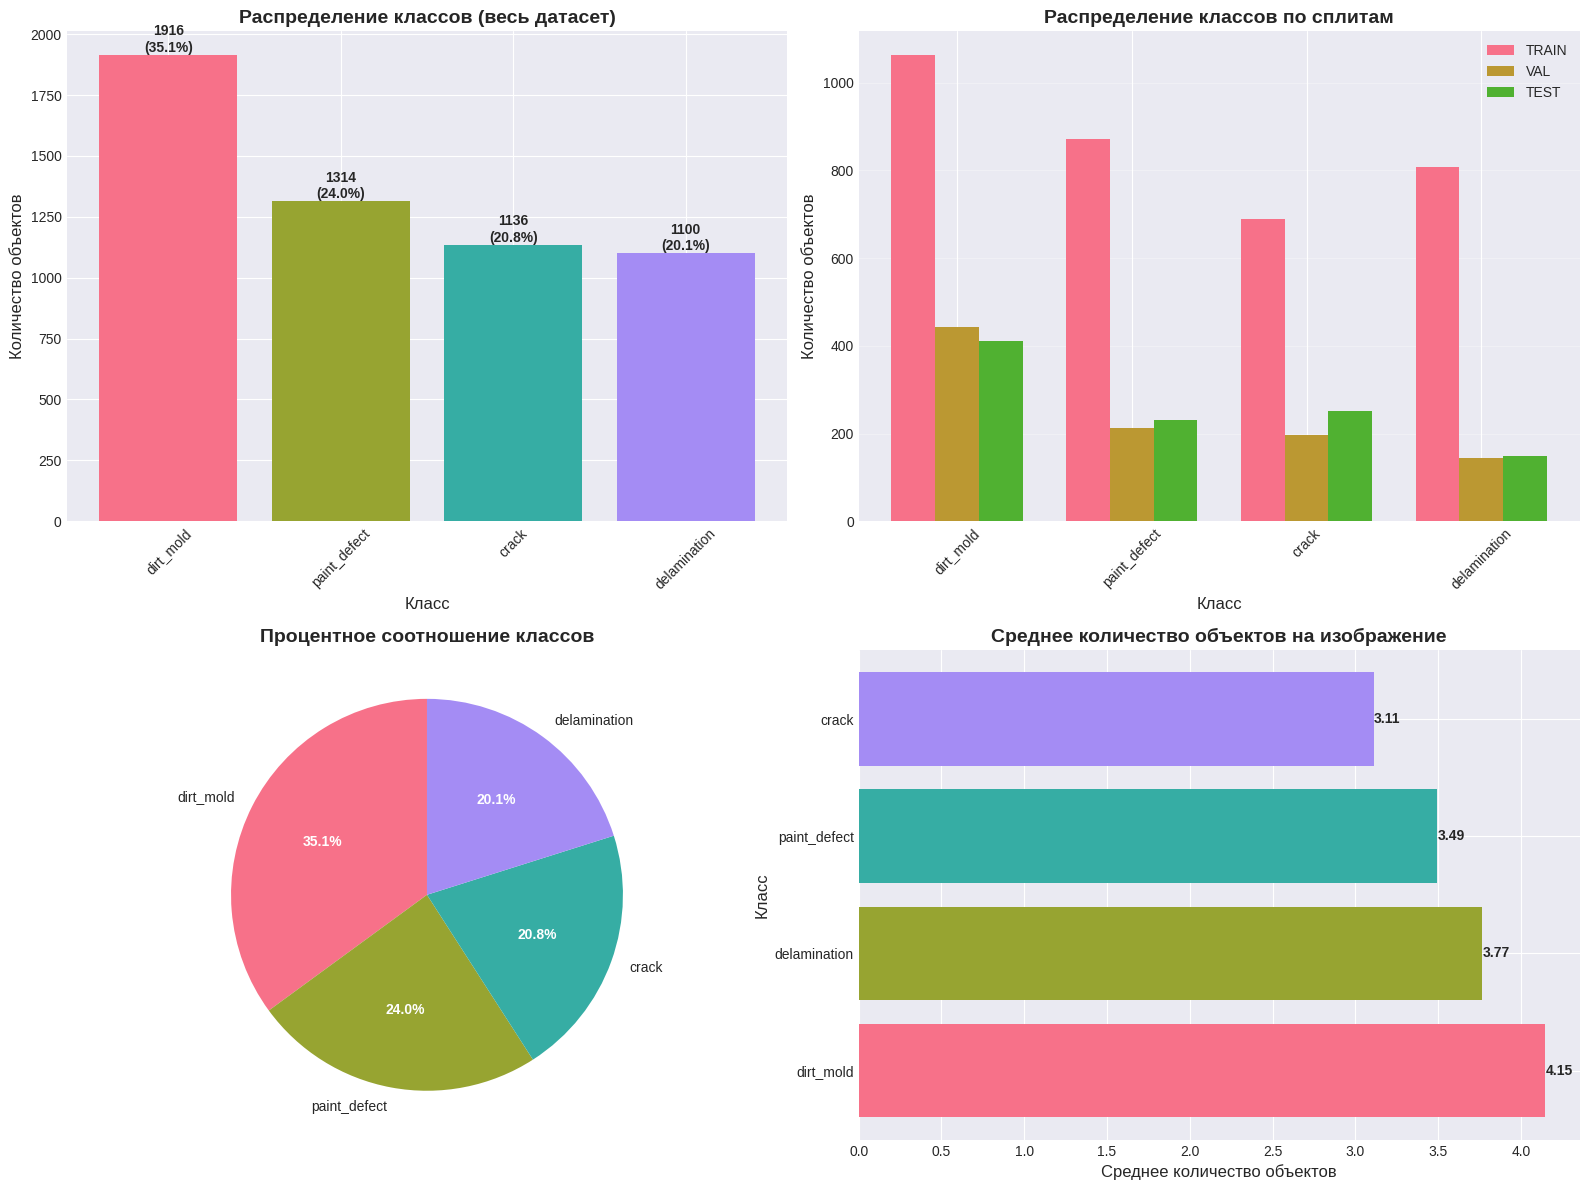


✓ Графики распределения классов построены


In [40]:
# Визуализация распределения классов
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# График 1: Распределение по всему датасету
ax1 = axes[0, 0]
classes_sorted = sorted(all_classes.items(), key=lambda x: x[1], reverse=True)
class_names = [c[0] for c in classes_sorted]
class_counts = [c[1] for c in classes_sorted]

bars1 = ax1.bar(class_names, class_counts, color=sns.color_palette("husl", len(class_names)))
ax1.set_title('Распределение классов (весь датасет)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Количество объектов', fontsize=12)
ax1.set_xlabel('Класс', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Добавляем значения на столбцы
for i, (bar, count) in enumerate(zip(bars1, class_counts)):
    height = bar.get_height()
    percentage = (count / total_objects) * 100
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{count}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# График 2: Сравнение по сплитам (stacked bar)
ax2 = axes[0, 1]
splits_data = {}
for split_name in ['train', 'val', 'test']:
    split_view = dataset.match_tags(split_name)
    split_classes = count_class_distribution(split_view, 'ground_truth')
    splits_data[split_name] = [split_classes.get(c, 0) for c in class_names]

x = np.arange(len(class_names))
width = 0.25

for i, (split_name, counts) in enumerate(splits_data.items()):
    ax2.bar(x + i*width, counts, width, label=split_name.upper())

ax2.set_title('Распределение классов по сплитам', fontsize=14, fontweight='bold')
ax2.set_ylabel('Количество объектов', fontsize=12)
ax2.set_xlabel('Класс', fontsize=12)
ax2.set_xticks(x + width)
ax2.set_xticklabels(class_names, rotation=45)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# График 3: Процентное соотношение классов (pie chart)
ax3 = axes[1, 0]
colors = sns.color_palette("husl", len(class_names))
wedges, texts, autotexts = ax3.pie(class_counts, labels=class_names, autopct='%1.1f%%',
                                     colors=colors, startangle=90)
ax3.set_title('Процентное соотношение классов', fontsize=14, fontweight='bold')

# Улучшаем читаемость процентов
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

# График 4: Количество объектов на изображение по классам
ax4 = axes[1, 1]
objects_per_image = {}

for class_name in class_names:
    # Считаем количество изображений, где встречается класс
    images_with_class = 0
    total_objects_of_class = 0
    
    for sample in dataset.iter_samples():
        if sample.ground_truth and sample.ground_truth.detections:
            class_count_in_sample = sum(1 for det in sample.ground_truth.detections if det.label == class_name)
            if class_count_in_sample > 0:
                images_with_class += 1
                total_objects_of_class += class_count_in_sample
    
    avg_per_image = total_objects_of_class / images_with_class if images_with_class > 0 else 0
    objects_per_image[class_name] = avg_per_image

class_names_sorted = sorted(objects_per_image.keys(), key=lambda x: objects_per_image[x], reverse=True)
avg_counts = [objects_per_image[c] for c in class_names_sorted]

bars4 = ax4.barh(class_names_sorted, avg_counts, color=sns.color_palette("husl", len(class_names_sorted)))
ax4.set_title('Среднее количество объектов на изображение', fontsize=14, fontweight='bold')
ax4.set_xlabel('Среднее количество объектов', fontsize=12)
ax4.set_ylabel('Класс', fontsize=12)

# Добавляем значения
for bar, count in zip(bars4, avg_counts):
    width = bar.get_width()
    ax4.text(width, bar.get_y() + bar.get_height()/2.,
             f'{count:.2f}',
             ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Графики распределения классов построены")

### 8.2 Анализ размеров и характеристик bounding boxes

In [41]:
# Функция для извлечения характеристик bbox
def extract_bbox_stats(view, field='ground_truth'):
    """
    Извлекает статистики bounding boxes: площадь, aspect ratio, координаты.
    
    Args:
        view: FiftyOne view или dataset
        field: название поля с детекциями
    
    Returns:
        pandas DataFrame с характеристиками каждого bbox
    """
    bbox_data = []
    
    for sample in view.iter_samples(progress=True):
        detections = sample[field]
        if detections and detections.detections:
            for det in detections.detections:
                # bbox в формате [x, y, width, height] (относительные координаты 0-1)
                x, y, w, h = det.bounding_box
                
                # Вычисляем характеристики
                area = w * h  # площадь в относительных координатах
                aspect_ratio = w / h if h > 0 else 0  # соотношение сторон
                center_x = x + w/2
                center_y = y + h/2
                
                bbox_data.append({
                    'class': det.label,
                    'area': area,
                    'width': w,
                    'height': h,
                    'aspect_ratio': aspect_ratio,
                    'center_x': center_x,
                    'center_y': center_y,
                })
    
    return pd.DataFrame(bbox_data)

print("📦 Извлечение характеристик bounding boxes...")
bbox_df = extract_bbox_stats(dataset, 'ground_truth')

print(f"\n✓ Обработано {len(bbox_df)} bounding boxes")
print(f"\n📊 Общая статистика по площади bbox:")
print(bbox_df['area'].describe())

print(f"\n📊 Общая статистика по aspect ratio:")
print(bbox_df['aspect_ratio'].describe())

📦 Извлечение характеристик bounding boxes...
 100% |█████████████████| 807/807 [1.6s elapsed, 0s remaining, 450.0 samples/s]         

✓ Обработано 5466 bounding boxes

📊 Общая статистика по площади bbox:
count    5466.000000
mean        0.026367
std         0.073144
min         0.000005
25%         0.001912
50%         0.005646
75%         0.018191
max         0.956729
Name: area, dtype: float64

📊 Общая статистика по aspect ratio:
count    5466.000000
mean        1.716708
std         2.520144
min         0.016175
25%         0.535624
50%         1.000000
75%         1.936439
max        50.000000
Name: aspect_ratio, dtype: float64


In [42]:
# Детальная статистика по классам
print("\n" + "="*80)
print("📊 СТАТИСТИКА РАЗМЕРОВ BBOX ПО КЛАССАМ")
print("="*80)

for class_name in sorted(bbox_df['class'].unique()):
    class_df = bbox_df[bbox_df['class'] == class_name]
    
    print(f"\n{class_name.upper()} ({len(class_df)} объектов):")
    print(f"  Площадь (area):")
    print(f"    Средняя:  {class_df['area'].mean():.6f}")
    print(f"    Медиана:  {class_df['area'].median():.6f}")
    print(f"    Мин/Макс: {class_df['area'].min():.6f} / {class_df['area'].max():.6f}")
    print(f"    Std:      {class_df['area'].std():.6f}")
    
    print(f"  Ширина (width):")
    print(f"    Средняя:  {class_df['width'].mean():.6f}")
    print(f"    Медиана:  {class_df['width'].median():.6f}")
    
    print(f"  Высота (height):")
    print(f"    Средняя:  {class_df['height'].mean():.6f}")
    print(f"    Медиана:  {class_df['height'].median():.6f}")
    
    print(f"  Aspect Ratio (ширина/высота):")
    print(f"    Средний:  {class_df['aspect_ratio'].mean():.3f}")
    print(f"    Медиана:  {class_df['aspect_ratio'].median():.3f}")
    
    # Категоризация размеров (мелкие, средние, крупные)
    small = (class_df['area'] < 0.01).sum()
    medium = ((class_df['area'] >= 0.01) & (class_df['area'] < 0.05)).sum()
    large = (class_df['area'] >= 0.05).sum()
    
    print(f"  Распределение по размеру:")
    print(f"    Мелкие (area < 0.01):     {small:5d} ({small/len(class_df)*100:5.1f}%)")
    print(f"    Средние (0.01 ≤ area < 0.05): {medium:5d} ({medium/len(class_df)*100:5.1f}%)")
    print(f"    Крупные (area ≥ 0.05):    {large:5d} ({large/len(class_df)*100:5.1f}%)")


📊 СТАТИСТИКА РАЗМЕРОВ BBOX ПО КЛАССАМ

CRACK (1136 объектов):
  Площадь (area):
    Средняя:  0.034381
    Медиана:  0.005199
    Мин/Макс: 0.000028 / 0.931641
    Std:      0.097755
  Ширина (width):
    Средняя:  0.124548
    Медиана:  0.064648
  Высота (height):
    Средняя:  0.161184
    Медиана:  0.082849
  Aspect Ratio (ширина/высота):
    Средний:  1.643
    Медиана:  0.731
  Распределение по размеру:
    Мелкие (area < 0.01):       712 ( 62.7%)
    Средние (0.01 ≤ area < 0.05):   267 ( 23.5%)
    Крупные (area ≥ 0.05):      157 ( 13.8%)

DELAMINATION (1100 объектов):
  Площадь (area):
    Средняя:  0.027679
    Медиана:  0.004437
    Мин/Макс: 0.000011 / 0.916716
    Std:      0.078343
  Ширина (width):
    Средняя:  0.115240
    Медиана:  0.064062
  Высота (height):
    Средняя:  0.119296
    Медиана:  0.064864
  Aspect Ratio (ширина/высота):
    Средний:  1.293
    Медиана:  0.961
  Распределение по размеру:
    Мелкие (area < 0.01):       755 ( 68.6%)
    Средние (0.01 ≤ ar

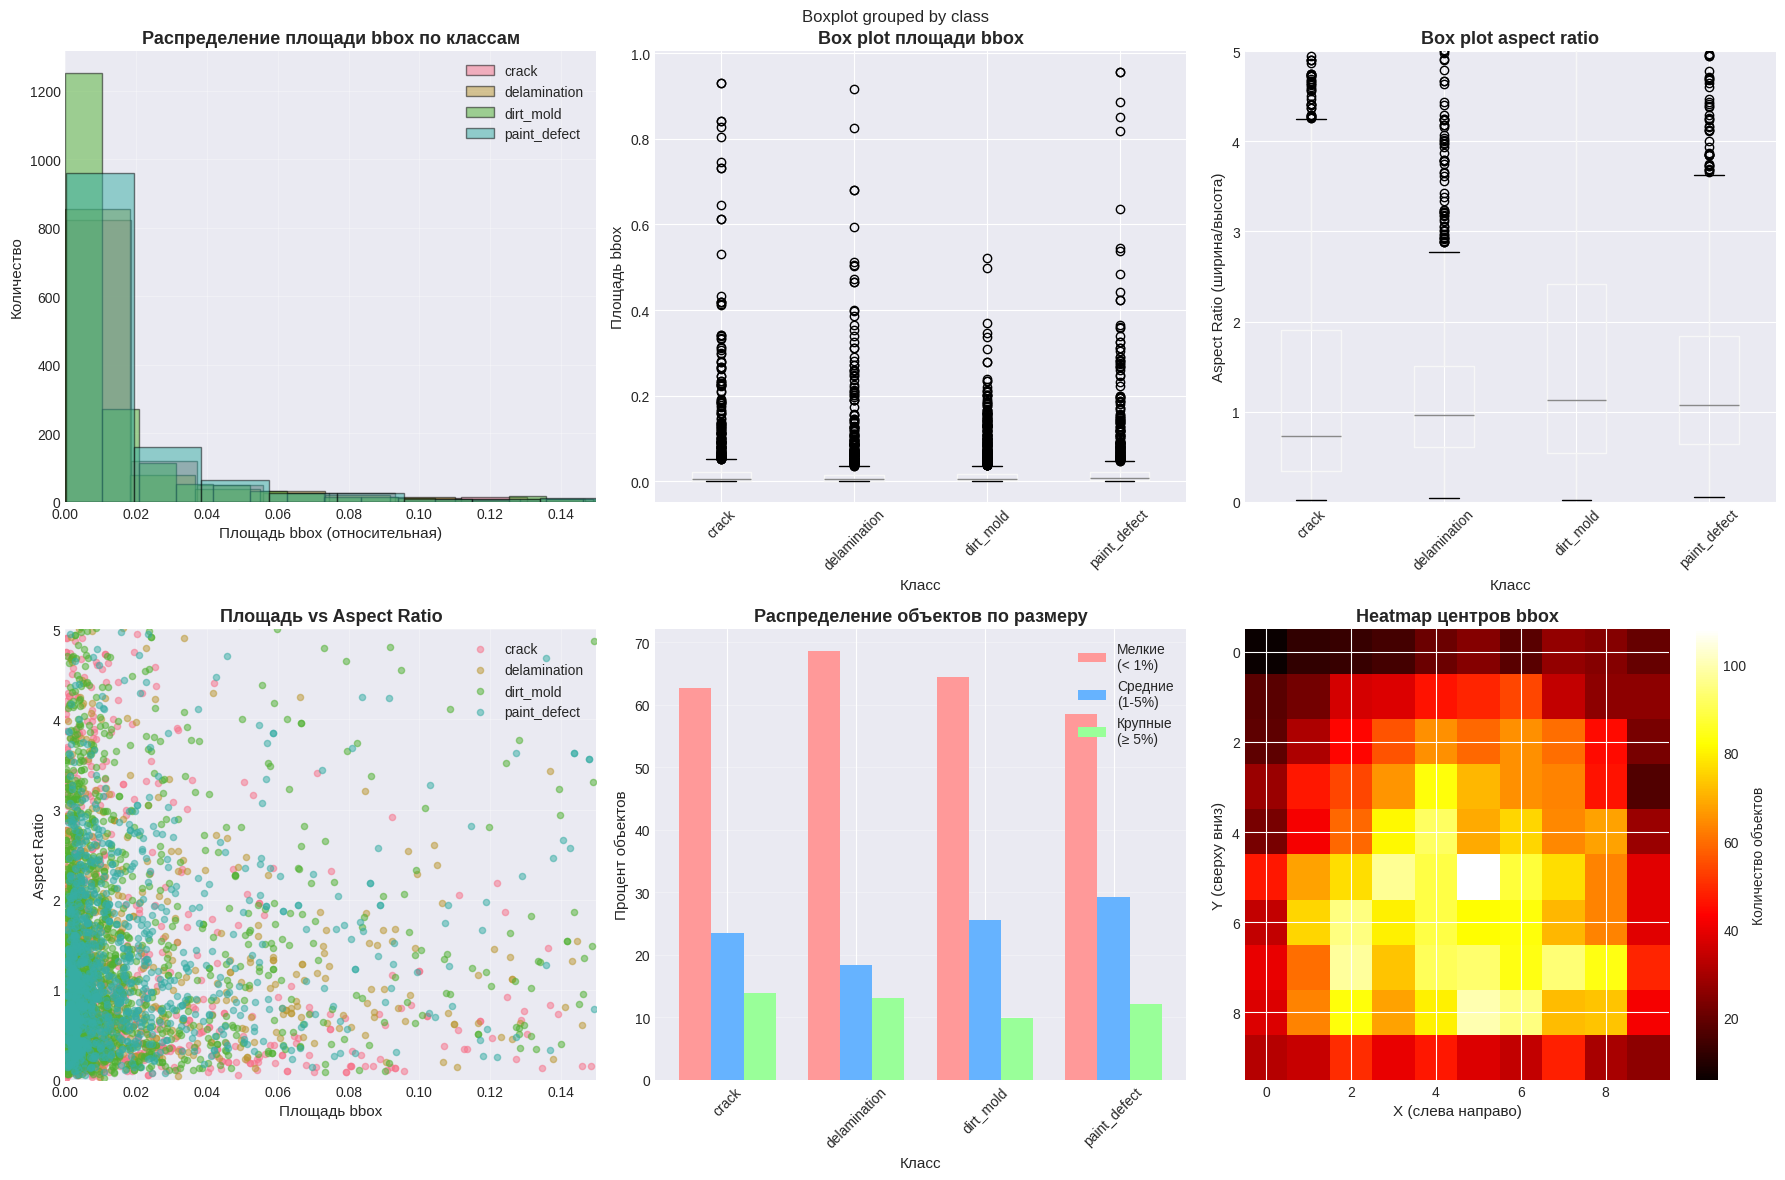


✓ Графики размеров bbox построены


In [43]:
# Визуализация размеров bbox
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# График 1: Распределение площади bbox
ax1 = axes[0, 0]
for class_name in sorted(bbox_df['class'].unique()):
    class_data = bbox_df[bbox_df['class'] == class_name]['area']
    ax1.hist(class_data, bins=50, alpha=0.5, label=class_name, edgecolor='black')
ax1.set_xlabel('Площадь bbox (относительная)', fontsize=11)
ax1.set_ylabel('Количество', fontsize=11)
ax1.set_title('Распределение площади bbox по классам', fontsize=13, fontweight='bold')
ax1.legend()
ax1.set_xlim(0, 0.15)  # Ограничим для лучшей видимости
ax1.grid(alpha=0.3)

# График 2: Box plot площади по классам
ax2 = axes[0, 1]
bbox_df.boxplot(column='area', by='class', ax=ax2)
ax2.set_xlabel('Класс', fontsize=11)
ax2.set_ylabel('Площадь bbox', fontsize=11)
ax2.set_title('Box plot площади bbox', fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
plt.sca(ax2)
plt.xticks(rotation=45)

# График 3: Aspect ratio по классам
ax3 = axes[0, 2]
bbox_df.boxplot(column='aspect_ratio', by='class', ax=ax3)
ax3.set_xlabel('Класс', fontsize=11)
ax3.set_ylabel('Aspect Ratio (ширина/высота)', fontsize=11)
ax3.set_title('Box plot aspect ratio', fontsize=13, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.set_ylim(0, 5)  # Ограничим для лучшей видимости
plt.sca(ax3)
plt.xticks(rotation=45)

# График 4: Scatter plot площади vs aspect ratio
ax4 = axes[1, 0]
for class_name in sorted(bbox_df['class'].unique()):
    class_data = bbox_df[bbox_df['class'] == class_name]
    ax4.scatter(class_data['area'], class_data['aspect_ratio'], 
                alpha=0.5, label=class_name, s=20)
ax4.set_xlabel('Площадь bbox', fontsize=11)
ax4.set_ylabel('Aspect Ratio', fontsize=11)
ax4.set_title('Площадь vs Aspect Ratio', fontsize=13, fontweight='bold')
ax4.legend()
ax4.set_xlim(0, 0.15)
ax4.set_ylim(0, 5)
ax4.grid(alpha=0.3)

# График 5: Распределение размеров (мелкие/средние/крупные)
ax5 = axes[1, 1]
size_categories = {'Мелкие\n(< 1%)': [], 'Средние\n(1-5%)': [], 'Крупные\n(≥ 5%)': []}

for class_name in sorted(bbox_df['class'].unique()):
    class_df = bbox_df[bbox_df['class'] == class_name]
    total = len(class_df)
    
    small = (class_df['area'] < 0.01).sum() / total * 100
    medium = ((class_df['area'] >= 0.01) & (class_df['area'] < 0.05)).sum() / total * 100
    large = (class_df['area'] >= 0.05).sum() / total * 100
    
    size_categories['Мелкие\n(< 1%)'].append(small)
    size_categories['Средние\n(1-5%)'].append(medium)
    size_categories['Крупные\n(≥ 5%)'].append(large)

x = np.arange(len(sorted(bbox_df['class'].unique())))
width = 0.25

colors_size = ['#ff9999', '#66b3ff', '#99ff99']
for i, (size_cat, percentages) in enumerate(size_categories.items()):
    ax5.bar(x + i*width, percentages, width, label=size_cat, color=colors_size[i])

ax5.set_ylabel('Процент объектов', fontsize=11)
ax5.set_xlabel('Класс', fontsize=11)
ax5.set_title('Распределение объектов по размеру', fontsize=13, fontweight='bold')
ax5.set_xticks(x + width)
ax5.set_xticklabels(sorted(bbox_df['class'].unique()), rotation=45)
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# График 6: Heatmap центров bbox
ax6 = axes[1, 2]
# Создаем 10x10 grid и считаем количество центров в каждой ячейке
heatmap_data = np.zeros((10, 10))
for _, row in bbox_df.iterrows():
    x_bin = min(int(row['center_x'] * 10), 9)
    y_bin = min(int(row['center_y'] * 10), 9)
    heatmap_data[y_bin, x_bin] += 1

im = ax6.imshow(heatmap_data, cmap='hot', interpolation='nearest', aspect='auto')
ax6.set_title('Heatmap центров bbox', fontsize=13, fontweight='bold')
ax6.set_xlabel('X (слева направо)', fontsize=11)
ax6.set_ylabel('Y (сверху вниз)', fontsize=11)
plt.colorbar(im, ax=ax6, label='Количество объектов')

plt.tight_layout()
plt.show()

print("\n✓ Графики размеров bbox построены")

## 9. Анализ качества модели

В этом разделе мы проанализируем ошибки модели:
- **False Negatives (FN)** - объекты, которые модель пропустила
- **False Positives (FP)** - объекты, которые модель предсказала ошибочно
- **True Positives (TP)** - корректные предсказания
- Confusion между классами
- Метрики качества по классам

In [29]:
# Используем встроенные методы FiftyOne для вычисления метрик
# Сначала нам нужно иметь view только с val и test (где есть предсказания)
view_with_preds = dataset.match(F('tags').contains('val') | F('tags').contains('test'))

print("📊 Вычисление метрик модели...")
print(f"Анализируем {len(view_with_preds)} изображений (val + test)\n")

# Используем FiftyOne для вычисления метрик детекции
# evaluate_detections сравнивает ground_truth и predictions
results = view_with_preds.evaluate_detections(
    "yolo_predictions",
    gt_field="ground_truth",
    eval_key="eval",
    compute_mAP=True,
    iou=0.5,  # IoU threshold для считывания TP
)

# Выводим основные метрики
print("\n" + "="*80)
print("📈 МЕТРИКИ МОДЕЛИ (IoU threshold = 0.5)")
print("="*80)
print(f"\nmAP (mean Average Precision): {results.mAP():.4f}")

# Метрики по классам
print("\n📊 Метрики по классам:\n")
print(f"{'Класс':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
print("-" * 75)

for class_name in sorted(all_classes.keys()):
    # Получаем метрики для класса
    class_metrics = results.metrics(classes=[class_name])
    
    precision = class_metrics.get('precision', 0)
    recall = class_metrics.get('recall', 0)
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    # Support - количество ground truth объектов этого класса
    support = 0
    for sample in view_with_preds.iter_samples():
        if sample.ground_truth and sample.ground_truth.detections:
            support += sum(1 for det in sample.ground_truth.detections if det.label == class_name)
    
    print(f"{class_name:<15} {precision:>11.4f} {recall:>11.4f} {f1:>11.4f} {support:>9d}")

print("\n✓ Метрики вычислены и сохранены в поле 'eval' датасета")

# Дополнительно: показываем общие метрики
print("\n" + "="*80)
print("📊 SUMMARY")
print("="*80)
overall_metrics = results.metrics()
print(f"\nOverall Precision: {overall_metrics.get('precision', 0):.4f}")
print(f"Overall Recall: {overall_metrics.get('recall', 0):.4f}")
print(f"Overall mAP@0.5: {results.mAP():.4f}")

print("\n💡 Для детального отчета с AP по классам используйте:")
print("   results.print_report()")


📊 Вычисление метрик модели...
Анализируем 653 изображений (val + test)

Evaluating detections...
 100% |█████████████████| 653/653 [10.0s elapsed, 0s remaining, 118.3 samples/s]     
Performing IoU sweep...
 100% |█████████████████| 653/653 [7.3s elapsed, 0s remaining, 127.9 samples/s]      

📈 МЕТРИКИ МОДЕЛИ (IoU threshold = 0.5)

mAP (mean Average Precision): 0.2433

📊 Метрики по классам:

Класс           Precision    Recall       F1-Score     Support   
---------------------------------------------------------------------------
corrosion            0.4732      0.2880      0.3581       184
crack                0.5295      0.4604      0.4925      1110
delamination         0.5539      0.5476      0.5507       798
dirt_mold            0.5532      0.4754      0.5113      1706
paint_defect         0.6629      0.6724      0.6676      1053

✓ Метрики вычислены и сохранены в поле 'eval' датасета

📊 SUMMARY

Overall Precision: 0.5658
Overall Recall: 0.5195
Overall mAP@0.5: 0.2433

💡 Для детал

### 9.1 Анализ False Negatives (пропущенных объектов)

In [30]:
# Анализ False Negatives - объектов, которые модель пропустила
print("="*80)
print("🔍 АНАЛИЗ FALSE NEGATIVES (пропущенных объектов)")
print("="*80)

fn_stats = defaultdict(lambda: {'count': 0, 'sizes': [], 'confidences': []})

# Проходим по всем изображениям с предсказаниями
for sample in view_with_preds.iter_samples(progress=True):
    if not sample.ground_truth or not sample.ground_truth.detections:
        continue
    
    # Для каждого GT объекта проверяем, был ли он детектирован
    for gt_det in sample.ground_truth.detections:
        # Проверяем eval_id - если None, значит не было совпадения (FN)
        if hasattr(gt_det, 'eval') and gt_det.eval is not None:
            # Если eval == "fn", это False Negative
            if gt_det.eval == "fn":
                class_name = gt_det.label
                fn_stats[class_name]['count'] += 1
                
                # Сохраняем размер bbox
                x, y, w, h = gt_det.bounding_box
                area = w * h
                fn_stats[class_name]['sizes'].append(area)

print(f"\n📊 Статистика False Negatives:\n")
print(f"{'Класс':<15} {'FN Count':<12} {'Средняя площадь':<20} {'Медианная площадь':<20}")
print("-" * 70)

total_fn = 0
for class_name in sorted(fn_stats.keys()):
    count = fn_stats[class_name]['count']
    total_fn += count
    
    sizes = fn_stats[class_name]['sizes']
    avg_size = np.mean(sizes) if sizes else 0
    median_size = np.median(sizes) if sizes else 0
    
    print(f"{class_name:<15} {count:>11d} {avg_size:>19.6f} {median_size:>19.6f}")

print(f"\n{'ВСЕГО FN':<15} {total_fn:>11d}")

# Анализ размеров пропущенных объектов
print(f"\n📊 Распределение FN по размерам:\n")
print(f"{'Класс':<15} {'Мелкие (<1%)':<15} {'Средние (1-5%)':<18} {'Крупные (≥5%)':<18}")
print("-" * 70)

for class_name in sorted(fn_stats.keys()):
    sizes = fn_stats[class_name]['sizes']
    if not sizes:
        continue
    
    small = sum(1 for s in sizes if s < 0.01)
    medium = sum(1 for s in sizes if 0.01 <= s < 0.05)
    large = sum(1 for s in sizes if s >= 0.05)
    total = len(sizes)
    
    print(f"{class_name:<15} {small:>6d} ({small/total*100:>4.1f}%) {medium:>7d} ({medium/total*100:>4.1f}%) {large:>8d} ({large/total*100:>4.1f}%)")

🔍 АНАЛИЗ FALSE NEGATIVES (пропущенных объектов)
 100% |█████████████████| 653/653 [2.4s elapsed, 0s remaining, 326.7 samples/s]      

📊 Статистика False Negatives:

Класс           FN Count     Средняя площадь      Медианная площадь   
----------------------------------------------------------------------
corrosion               131            0.027418            0.008672
crack                   599            0.013045            0.001388
delamination            361            0.017930            0.001705
dirt_mold               895            0.012812            0.002478
paint_defect            345            0.027392            0.006448

ВСЕГО FN               2331

📊 Распределение FN по размерам:

Класс           Мелкие (<1%)    Средние (1-5%)     Крупные (≥5%)     
----------------------------------------------------------------------
corrosion           71 (54.2%)      42 (32.1%)       18 (13.7%)
crack              480 (80.1%)      87 (14.5%)       32 ( 5.3%)
delamination       2

### 9.2 Анализ False Positives (ложных детекций)

In [31]:
# Анализ False Positives - объектов, которые модель предсказала ошибочно
print("="*80)
print("🔍 АНАЛИЗ FALSE POSITIVES (ложных детекций)")
print("="*80)

fp_stats = defaultdict(lambda: {'count': 0, 'confidences': [], 'sizes': []})

# Проходим по всем изображениям с предсказаниями
for sample in view_with_preds.iter_samples(progress=True):
    if not sample.yolo_predictions or not sample.yolo_predictions.detections:
        continue
    
    # Для каждого предсказания проверяем, было ли оно корректным
    for pred_det in sample.yolo_predictions.detections:
        if hasattr(pred_det, 'eval') and pred_det.eval is not None:
            # Если eval == "fp", это False Positive
            if pred_det.eval == "fp":
                class_name = pred_det.label
                fp_stats[class_name]['count'] += 1
                fp_stats[class_name]['confidences'].append(pred_det.confidence)
                
                # Сохраняем размер bbox
                x, y, w, h = pred_det.bounding_box
                area = w * h
                fp_stats[class_name]['sizes'].append(area)

print(f"\n📊 Статистика False Positives:\n")
print(f"{'Класс':<15} {'FP Count':<12} {'Средний conf':<15} {'Медианный conf':<18}")
print("-" * 65)

total_fp = 0
for class_name in sorted(fp_stats.keys()):
    count = fp_stats[class_name]['count']
    total_fp += count
    
    confidences = fp_stats[class_name]['confidences']
    avg_conf = np.mean(confidences) if confidences else 0
    median_conf = np.median(confidences) if confidences else 0
    
    print(f"{class_name:<15} {count:>11d} {avg_conf:>14.4f} {median_conf:>17.4f}")

print(f"\n{'ВСЕГО FP':<15} {total_fp:>11d}")

# Анализ confidence FP
print(f"\n📊 Распределение FP по confidence:\n")
print(f"{'Класс':<15} {'Low (<0.5)':<13} {'Medium (0.5-0.7)':<20} {'High (≥0.7)':<15}")
print("-" * 65)

for class_name in sorted(fp_stats.keys()):
    confidences = fp_stats[class_name]['confidences']
    if not confidences:
        continue
    
    low = sum(1 for c in confidences if c < 0.5)
    medium = sum(1 for c in confidences if 0.5 <= c < 0.7)
    high = sum(1 for c in confidences if c >= 0.7)
    total = len(confidences)
    
    print(f"{class_name:<15} {low:>5d} ({low/total*100:>4.1f}%) {medium:>8d} ({medium/total*100:>4.1f}%) {high:>6d} ({high/total*100:>4.1f}%)")

🔍 АНАЛИЗ FALSE POSITIVES (ложных детекций)
 100% |█████████████████| 653/653 [2.2s elapsed, 0s remaining, 328.3 samples/s]      

📊 Статистика False Positives:

Класс           FP Count     Средний conf    Медианный conf    
-----------------------------------------------------------------
corrosion                59         0.4361            0.3871
crack                   454         0.4443            0.4086
delamination            352         0.4605            0.4113
dirt_mold               655         0.4602            0.4192
paint_defect            360         0.5037            0.4540
rust                     54         0.5566            0.4260

ВСЕГО FP               1934

📊 Распределение FP по confidence:

Класс           Low (<0.5)    Medium (0.5-0.7)     High (≥0.7)    
-----------------------------------------------------------------
corrosion          39 (66.1%)       16 (27.1%)      4 ( 6.8%)
crack             304 (67.0%)      115 (25.3%)     35 ( 7.7%)
delamination      225

## 10. Создание Views для визуального анализа в FiftyOne UI

Теперь создадим специальные views, которые можно будет открыть в FiftyOne UI для детального визуального анализа проблемных случаев.

In [34]:
# Создание views для анализа проблемных случаев
print("="*80)
print("🔎 СОЗДАНИЕ VIEWS ДЛЯ ВИЗУАЛЬНОГО АНАЛИЗА")
print("="*80)

# 1. View с изображениями, содержащими много FN
print("\n1️⃣ Создание view с изображениями с большим количеством False Negatives...")

# Подсчитаем количество FN на каждом изображении
fn_counts = []
for sample in view_with_preds.iter_samples():
    if not sample.ground_truth or not sample.ground_truth.detections:
        continue
    
    fn_count = sum(1 for det in sample.ground_truth.detections 
                   if hasattr(det, 'eval') and det.eval == 'fn')
    
    # Сохраняем в sample для последующей фильтрации
    sample['fn_count'] = fn_count
    sample.save()
    fn_counts.append(fn_count)

# Находим изображения с количеством FN выше 75-го перцентиля
if fn_counts:
    fn_threshold = np.percentile(fn_counts, 75)
    view_high_fn = view_with_preds.match(F('fn_count') > fn_threshold).sort_by('fn_count', reverse=True)
    print(f"   ✓ View создан: {len(view_high_fn)} изображений с FN > {fn_threshold:.0f}")
    print(f"   Используйте: session = fo.launch_app(view_high_fn)")
else:
    print("   ⚠ Нет данных о FN")

# 2. View с изображениями, содержащими много FP
print("\n2️⃣ Создание view с изображениями с большим количеством False Positives...")

fp_counts = []
for sample in view_with_preds.iter_samples():
    if not sample.yolo_predictions or not sample.yolo_predictions.detections:
        continue
    
    fp_count = sum(1 for det in sample.yolo_predictions.detections 
                   if hasattr(det, 'eval') and det.eval == 'fp')
    
    sample['fp_count'] = fp_count
    sample.save()
    fp_counts.append(fp_count)

if fp_counts:
    fp_threshold = np.percentile(fp_counts, 75)
    view_high_fp = view_with_preds.match(F('fp_count') > fp_threshold).sort_by('fp_count', reverse=True)
    print(f"   ✓ View создан: {len(view_high_fp)} изображений с FP > {fp_threshold:.0f}")
    print(f"   Используйте: session = fo.launch_app(view_high_fp)")
else:
    print("   ⚠ Нет данных о FP")

# 3. View с изображениями, где модель хуже всего работает (много FN и FP)
print("\n3️⃣ Создание view с наихудшими предсказаниями...")

for sample in view_with_preds.iter_samples():
    # ИСПРАВЛЕНО: проверяем на None и используем 0 по умолчанию
    fn = getattr(sample, 'fn_count', None)
    fp = getattr(sample, 'fp_count', None)
    
    # Если значения None, используем 0
    fn = fn if fn is not None else 0
    fp = fp if fp is not None else 0
    
    sample['error_score'] = fn + fp  # Простая метрика ошибок
    sample.save()

view_worst = view_with_preds.match(F('error_score') > 0).sort_by('error_score', reverse=True).limit(50)
print(f"   ✓ View создан: топ-50 изображений с наибольшим количеством ошибок")
print(f"   Используйте: session = fo.launch_app(view_worst)")


# 4. View с мелкими объектами (которые часто пропускаются)
print("\n4️⃣ Создание view с изображениями, содержащими мелкие объекты...")

# Находим изображения с мелкими объектами в GT
view_small_objects = view_with_preds.filter_labels(
    "ground_truth",
    (F("bounding_box")[2] * F("bounding_box")[3]) < 0.01  # area < 0.01
)

print(f"   ✓ View создан: {len(view_small_objects)} изображений с мелкими объектами (area < 0.01)")
print(f"   Используйте: session = fo.launch_app(view_small_objects)")

# 5. View по конкретным классам с проблемами
print("\n5️⃣ Создание views по классам с низким recall...")

problem_classes = ['crack', 'corrosion']  # Классы с низким recall по нашему анализу

for class_name in problem_classes:
    # Изображения, где есть этот класс в GT, но модель его пропустила
    view_class_fn = view_with_preds.filter_labels(
        "ground_truth",
        (F("label") == class_name) & (F("eval") == "fn")
    )
    
    print(f"   ✓ View для класса '{class_name}': {len(view_class_fn)} изображений с FN")

print("\n" + "="*80)
print("✓ Все views созданы!")
print("="*80)
print("\nДля запуска анализа в FiftyOne UI используйте:")
print("  session = fo.launch_app(view_worst)  # или любой другой view")
print("\nСозданные views:")
print("  - view_high_fn: изображения с большим количеством FN")
print("  - view_high_fp: изображения с большим количеством FP")  
print("  - view_worst: топ-50 худших изображений")
print("  - view_small_objects: изображения с мелкими объектами")

🔎 СОЗДАНИЕ VIEWS ДЛЯ ВИЗУАЛЬНОГО АНАЛИЗА

1️⃣ Создание view с изображениями с большим количеством False Negatives...
   ✓ View создан: 159 изображений с FN > 5
   Используйте: session = fo.launch_app(view_high_fn)

2️⃣ Создание view с изображениями с большим количеством False Positives...
   ✓ View создан: 142 изображений с FP > 4
   Используйте: session = fo.launch_app(view_high_fp)

3️⃣ Создание view с наихудшими предсказаниями...
   ✓ View создан: топ-50 изображений с наибольшим количеством ошибок
   Используйте: session = fo.launch_app(view_worst)

4️⃣ Создание view с изображениями, содержащими мелкие объекты...
   ✓ View создан: 535 изображений с мелкими объектами (area < 0.01)
   Используйте: session = fo.launch_app(view_small_objects)

5️⃣ Создание views по классам с низким recall...
   ✓ View для класса 'crack': 208 изображений с FN
   ✓ View для класса 'corrosion': 41 изображений с FN

✓ Все views созданы!

Для запуска анализа в FiftyOne UI используйте:
  session = fo.launch_a

In [ ]:
from collections import Counter

# Загружаем датасет
dataset = fo.load_dataset("facade_damage_detection")

# Статистика ДО удаления
print("=" * 60)
print("СТАТИСТИКА ДО УДАЛЕНИЯ CORROSION")
print("=" * 60)

label_counts_before = Counter()
for sample in dataset.iter_samples(progress=True):
    if sample.ground_truth and sample.ground_truth.detections:
        for det in sample.ground_truth.detections:
            label_counts_before[det.label] += 1

total_before = sum(label_counts_before.values())
print(f"\nВсего объектов: {total_before}")
for label, count in sorted(label_counts_before.items()):
    pct = (count / total_before) * 100
    print(f"  {label:.<20} {count:>6} ({pct:>5.1f}%)")

corrosion_count = label_counts_before.get('corrosion', 0)
print(f"\n⚠ Объектов corrosion для удаления: {corrosion_count}")

## 11. Запуск визуального анализа в FiftyOne

Теперь вы можете запустить FiftyOne UI для визуального анализа созданных views.

In [ ]:
# Выберите один из views для визуального анализа:

# Вариант 1: Худшие 50 изображений (рекомендуется начать с этого)
# session = fo.launch_app(view_worst)

# Вариант 2: Изображения с большим количеством FN
# session = fo.launch_app(view_high_fn)

# Вариант 3: Изображения с большим количеством FP
# session = fo.launch_app(view_high_fp)

# Вариант 4: Изображения с мелкими объектами
# session = fo.launch_app(view_small_objects)

# Вариант 5: Все изображения с предсказаниями
# session = fo.launch_app(view_with_preds)

print(f"✓ FiftyOne UI запущен: {session.url}")
print("\n📝 В FiftyOne UI вы можете:")
print("  1. Просматривать изображения с GT и предсказаниями")
print("  2. Фильтровать по классам, confidence, eval статусу (tp/fp/fn)")
print("  3. Сортировать по количеству ошибок")
print("  4. Визуально оценивать качество разметки")
print("  5. Находить паттерны в ошибках модели")
print("\n💡 Совет: используйте фильтры в UI для более детального анализа!")

✓ FiftyOne UI запущен: http://localhost:5151/

📝 В FiftyOne UI вы можете:
  1. Просматривать изображения с GT и предсказаниями
  2. Фильтровать по классам, confidence, eval статусу (tp/fp/fn)
  3. Сортировать по количеству ошибок
  4. Визуально оценивать качество разметки
  5. Находить паттерны в ошибках модели

💡 Совет: используйте фильтры в UI для более детального анализа!


## Блок 13: Ручное удаление проблемных изображений

Запускаем FiftyOne UI с view проблемных изображений для ручного отбора и удаления

In [45]:
# Проверим какие датасеты есть
print("Доступные датасеты:")
print(fo.list_datasets())

# Если датасет есть в списке, попробуй:
# dataset = fo.load_dataset("facade_damage_detection")

# Если датасета нет совсем, значит он был удален. 
# В этом случае нужно загрузить заново из исходных файлов (ячейки из начала ноутбука)


Доступные датасеты:
['facade-damage-local']


In [47]:
# Проверка: сколько изображений осталось после удаления
dataset = fo.load_dataset("facade-damage-local")

total_before = 2840  # Исходное количество из вашего анализа
total_now = len(dataset)
deleted = total_before - total_now

print(f"✓ Удалено изображений: {deleted}")
print(f"✓ Осталось в датасете: {total_now}")
print(f"  - train: {len(dataset.match_tags('train'))}")
print(f"  - val: {len(dataset.match_tags('val'))}")
print(f"  - test: {len(dataset.match_tags('test'))}")

✓ Удалено изображений: 723
✓ Осталось в датасете: 2117
  - train: 1521
  - val: 294
  - test: 302


In [50]:
# Загружаем датасет
dataset = fo.load_dataset("facade-damage-local")

# ИСПРАВЛЕНО: Используем абсолютный путь
# Определяем базовую директорию проекта
base_dir = Path("/home/neuralist/HSE_AI_master/deep-learning")
output_dir = base_dir / "master-thesis/damage-analysis/data/detection/facade_damage_cleaned"

# Создаем директорию если не существует
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Рабочая директория Python: {os.getcwd()}")
print(f"Путь для экспорта: {output_dir}")
print(f"Путь существует: {output_dir.exists()}")

# Статистика
print("\n" + "=" * 60)
print("ЭКСПОРТ ОЧИЩЕННОГО ДАТАСЕТА")
print("=" * 60)
print(f"Всего изображений: {len(dataset)}")
print(f"  - train: {len(dataset.match_tags('train'))}")
print(f"  - val: {len(dataset.match_tags('val'))}")
print(f"  - test: {len(dataset.match_tags('test'))}")

# Определяем классы (проверяем есть ли еще corrosion)
all_classes = dataset.distinct('ground_truth.detections.label')
classes = sorted([c for c in all_classes if c != 'corrosion'])
print(f"\nКлассы для экспорта: {classes}")

# Экспортируем каждый split
for split in ['train', 'val', 'test']:
    split_view = dataset.match_tags(split)
    split_dir = output_dir / split
    
    print(f"\nЭкспорт {split}: {len(split_view)} изображений...")
    print(f"Путь: {split_dir}")
    
    split_view.export(
        export_dir=str(split_dir),  # Преобразуем Path в строку
        dataset_type=fo.types.YOLOv5Dataset,
        label_field="ground_truth",
        split=split,
        classes=classes,
    )
    
    # Проверяем что экспорт прошел
    if split_dir.exists():
        num_images = len(list((split_dir / "images").glob("*"))) if (split_dir / "images").exists() else 0
        num_labels = len(list((split_dir / "labels").glob("*"))) if (split_dir / "labels").exists() else 0
        print(f"✓ {split} экспортирован: {num_images} изображений, {num_labels} аннотаций")
    else:
        print(f"⚠ ОШИБКА: {split_dir} не создана!")

# Создаем общий data.yaml
data_yaml = {
    'path': str(output_dir.absolute()),
    'train': 'train/images',
    'val': 'val/images', 
    'test': 'test/images',
    'names': {i: name for i, name in enumerate(classes)}
}

yaml_path = output_dir / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print(f"\n✓ Создан {yaml_path}")
print("\nСодержимое data.yaml:")
with open(yaml_path, 'r') as f:
    print(f.read())

# Проверяем итоговую структуру
print(f"\n{'=' * 60}")
print("СТРУКТУРА ЭКСПОРТИРОВАННОГО ДАТАСЕТА")
print("=" * 60)

for split in ['train', 'val', 'test']:
    split_dir = output_dir / split
    if split_dir.exists():
        img_dir = split_dir / "images"
        lbl_dir = split_dir / "labels"
        
        num_img = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
        num_lbl = len(list(lbl_dir.glob("*"))) if lbl_dir.exists() else 0
        
        print(f"{split}:")
        print(f"  {img_dir}: {num_img} файлов")
        print(f"  {lbl_dir}: {num_lbl} файлов")

print(f"\n✓ Датасет готов: {output_dir}")

Рабочая директория Python: /home/neuralist/HSE_AI_master/deep-learning/master-thesis/damage-analysis/notebooks/detection
Путь для экспорта: /home/neuralist/HSE_AI_master/deep-learning/master-thesis/damage-analysis/data/detection/facade_damage_cleaned
Путь существует: True

ЭКСПОРТ ОЧИЩЕННОГО ДАТАСЕТА
Всего изображений: 2117
  - train: 1521
  - val: 294
  - test: 302

Классы для экспорта: ['crack', 'delamination', 'dirt_mold', 'paint_defect']

Экспорт train: 1521 изображений...
Путь: /home/neuralist/HSE_AI_master/deep-learning/master-thesis/damage-analysis/data/detection/facade_damage_cleaned/train
 100% |███████████████| 1521/1521 [3.9s elapsed, 0s remaining, 449.1 samples/s]      
✓ train экспортирован: 1 изображений, 1 аннотаций

Экспорт val: 294 изображений...
Путь: /home/neuralist/HSE_AI_master/deep-learning/master-thesis/damage-analysis/data/detection/facade_damage_cleaned/val
 100% |█████████████████| 294/294 [1.2s elapsed, 0s remaining, 247.6 samples/s]         
✓ val экспортиро

In [ ]:
# Шаг 2: Удаляем изображения где corrosion был единственным классом
print("\n" + "=" * 60)
print("ШАГ 2: Удаление изображений где corrosion - единственный класс")
print("=" * 60)

if samples_to_delete:
    dataset.delete_samples(samples_to_delete)
    print(f"✓ Удалено {len(samples_to_delete)} изображений")
else:
    print("✓ Нет изображений для удаления (везде были и другие классы)")

In [ ]:
# Статистика ПОСЛЕ удаления
print("\n" + "=" * 60)
print("СТАТИСТИКА ПОСЛЕ УДАЛЕНИЯ CORROSION")
print("=" * 60)

label_counts_after = Counter()
for sample in dataset.iter_samples(progress=True):
    if sample.ground_truth and sample.ground_truth.detections:
        for det in sample.ground_truth.detections:
            label_counts_after[det.label] += 1

total_after = sum(label_counts_after.values())
print(f"\nВсего объектов: {total_after} (было {total_before})")
print(f"Удалено объектов: {total_before - total_after}")

for label, count in sorted(label_counts_after.items()):
    pct = (count / total_after) * 100
    print(f"  {label:.<20} {count:>6} ({pct:>5.1f}%)")

print(f"\n✓ Класс corrosion полностью удален: {'corrosion' not in label_counts_after}")
print(f"✓ Изображений в датасете: {len(dataset)}")
print(f"  - train: {len(dataset.match_tags('train'))}")
print(f"  - val: {len(dataset.match_tags('val'))}")
print(f"  - test: {len(dataset.match_tags('test'))}")
